# 당뇨병 여부 분류
1. 데이터 로드
2. train / valid / test 데이터 분리
3. 결측치 처리 및 정규화
4. Tensor 변환
5. 미니배치 학습 준비
6. 다층 퍼셉트론 모델 준비
7. Optimizer / Scheduler / EarlyStopping 적용하여 학습
8. 학습 시각화
9. 각종 지표 확인
10. Optimizer 여러개 성능 비교
11. K-Fold Cross Validation

- 데이터셋
jamaltariqcheema/pima-indians-diabetes-dataset

- y : outcome  
0 -> 당뇨병 음성  
1 -> 당뇨병 양성

In [1]:
import os 
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn                                   # 신경망 구성 및 손실함수
from torch.utils.data import TensorDataset, DataLoader  # Tensor 데이터셋 / 미니배치 로더

import kagglehub
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold   # 데이터 분리 / K-Fold 검증
from sklearn.pipeline import Pipeline       # 전처리 과정 통합
from sklearn.impute import SimpleImputer    # 결측치 처리
from sklearn.preprocessing import StandardScaler    # 표준화
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

c:\Users\playdata2\DL\dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42   # 랜덤 시드값

random.seed(SEED)       # 파이썬 random 시드 고정
np.random.seed(SEED)    # numpy 랜덤 시드 고정
torch.manual_seed(SEED) # Pytorch CPU 랜덤 시드 고정

# GPU 가용시
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)    # Pytoch GPU 랜덤 시드 고정

# GPU 가용시 device = 'cuda', 아니면 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

1. 데이터 로드

In [3]:
data_path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset", path='diabetes.csv')

df = pd.read_csv(data_path)

print(df.shape)
df

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

|컬럼명|설명|
|---|---|
|Pregnancies|임신 횟수|
|Glucose|포도당 수치|
|BloodPressure|혈압|
|SkinThickness|피부 두께|
|Insulin|인슐린|
|BMI|체질량지수|
|DiabetesPedigreeFunction|당뇨병 가족력 지표|
|Age|나이|
|Outcome|당뇨병 여부|

,count,ratio
Outcome,,
0,500,0.651042
1,268,0.348958


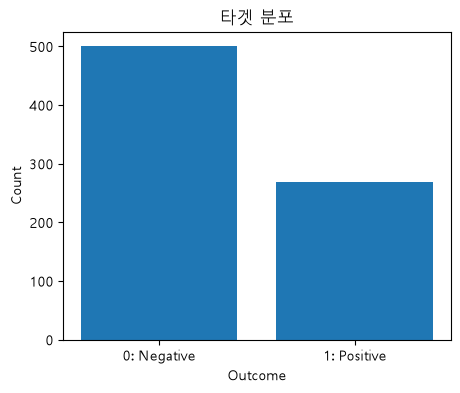

In [7]:
target_counts = df['Outcome'].value_counts().sort_index()   # 클래스별 데이터 갯수 
target_ratio = df['Outcome'].value_counts(normalize=True).sort_index()  # 클래스별 비율

# 갯수와 비율을 표로 출력
display(pd.DataFrame({
    'count': target_counts,
    'ratio': target_ratio
}))

plt.figure(figsize=(5, 4))
plt.bar(['0: Negative', '1: Positive'], target_counts.values)   # 클래스별 갯수 막대그래프
plt.title('타겟 분포')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

2. train / valid / test 데이터 분리

In [8]:
X = df.drop(columns='Outcome')
y = df['Outcome']

print(X.shape, y.shape)

(768, 8) (768,)


In [9]:
# test데이터를 8:2 비율로 나눈다 (전역 시드값 설정, y비율 유지)
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size= 0.2,     # 80:20
    random_state= 42,
    stratify= y         # 클래스 비율을 유지하면서 분할
)

# 남은 80% 중 8:2 비율로 train / valid 데이터를 나눈다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size = 0.2,      
    random_state = 42,
    stratify = y_train_valid   # y_train_valid의 클래스 비율 유지하면서 분할
)

print(f'X_train : {X_train.shape}, X_test : {X_test.shape}, X_valid : {X_valid.shape}, ')
print(f'y_train : {y_train.shape}, y_test : {y_test.shape}, y_valid : {y_valid.shape}, ')

X_train : (491, 8), X_test : (154, 8), X_valid : (123, 8), 
y_train : (491,), y_test : (154,), y_valid : (123,), 


In [10]:
preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # 결측치가 있다면 중앙값 대체
    ('scaler', StandardScaler())                    # 평균 0, 표준편차 1 표준화
])

X_train_scaled = preprocess_pipeline.fit_transform(X_train)     # train 데이터는 전처리 기준 학습 / 변환
X_valid_scaled = preprocess_pipeline.fit_transform(X_valid)     # valid 데이터는 학습된 기준으로 변환
X_test_scaled = preprocess_pipeline.fit_transform(X_test)       # test  데이터는 학습된 기준으로 변환

print(X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

(491, 8) (123, 8) (154, 8)


In [11]:
# 텐서 데이터로 변환 : y 데이터는 모델 학습 및 사용에 적합하도록 2차원 형태로 변환 
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

y_train_tensor = torch.FloatTensor(y_train.to_numpy()).reshape(-1, 1)
y_valid_tensor = torch.FloatTensor(y_valid.to_numpy()).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.to_numpy()).reshape(-1, 1)

print(X_train_tensor.shape, X_valid_tensor.shape, X_test_tensor.shape)
print(y_train_tensor.shape, y_valid_tensor.shape, y_test_tensor.shape)

torch.Size([491, 8]) torch.Size([123, 8]) torch.Size([154, 8])
torch.Size([491, 1]) torch.Size([123, 1]) torch.Size([154, 1])


C:\Users\playdata2\AppData\Local\Temp\ipykernel_17804\4268653889.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train.to_numpy()).reshape(-1, 1)


5. 미니배치 학습 준비

In [12]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)   
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)   
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)   

# DataLoader를 사용해서 미니배치 단위로 데이터를 나눠 학습
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)
print(len(train_loader), len(valid_loader), len(test_loader))

16 4 5


6. 다층 퍼셉트론 모델 정의

In [13]:
class DiabetesMLP(nn.Module):

    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.2, activation='silu'):
        super().__init__()  # 부모 클래스 초기화

        layers = [] # 신경망 계층을 모두 저장할 클래스
        prev_dim = input_dim    # 이전 계층의 출력 차원

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))   # 배치 정규화(평균 0, 표준편차 1) : 수치 안정화 -> 학습 안정화

            # 활성화 함수 추가 (비선형성 추가)
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'gelu':
                layers.append(nn.GELU())
            elif activation == 'silu':
                layers.append(nn.SiLU())
            else:
                raise ValueError("활성화함수는 relu, gelu, silu 중 하나로 선택해 주세요!")

            layers.append(nn.Dropout(dropout))  # 일부 파라미터 생략 (과적합 완화)
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))   # 이진 분류 출력층
        self.net = nn.Sequential(*layers)       # 계층들을 순서대로 연결

    def forward(self, x):
        return self.net(x)

In [14]:
input_dim = X_train_tensor.size(-1)

model = DiabetesMLP(input_dim = input_dim).to(device)

model

DiabetesMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [15]:
# 양성 클래스 비율이 낮을 때 양성 클래스에 더 큰 가중치를 부여하는 손실함수
num_positive = y_train_tensor.sum() # 양성 클래스 갯수
num_negative = len(y_train_tensor) - num_positive   # 음성 클래스 갯수
pos_weight = (num_negative / num_positive).to(device)   # 양성 클래스 가중치

print(f'양성 클래스 가중치 : {pos_weight}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # 이진 분류 손실 함수 (양성 가중치 부여)

optimizer = torch.optim.AdamW(
    model.parameters(),         # 학습할 모델 파라미터
    lr=0.001,                   
    weight_decay=1e-4           # 가중치 감쇠 (과적합 완화)
)

# 스케줄러 : 학습률을 조정하여 최대한 학습되도록 만드는 도구 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,      # 학습률 조정할 최적화함수
    mode = 'min',   # valid_loss가 작아지는 방향
    factor = 0.5,   # 학습률을 절반으로 감소
    patience = 5    # 개선이 5 epoch 동안 없으면 감소
)

양성 클래스 가중치 : 1.871345043182373


In [16]:
# EarlyStopping : 일정 epoch동안 성능이 좋아지지 않으면 학습을 멈추는 도구
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience    # 개선이 없을떄 기다릴 epoch 수
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best_loss = np.inf     # 현재까지 가장 낮은 valid loss
        self.counter = 0            # 개선이 없던 epoch 수
        self.best_state = None      # 가장 성능이 좋은 모델의 가중치
        self.should_stop = False    # 학습 중단 여부 플래그

    def step(self, valid_loss, model):
        # 최소 손실 갱신시
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0

            # 가장 좋은 모델의 가중치 저장
            self.best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            self.counter += 1

            # patience 동안 개선이 없을시
            if self.counter >= self.patience:
                self.should_stop = True # 학습 중단 신호

학습 함수와 검증 함수  
- 학습 과정
1. 예측값 계산
2. 손실 계산
3. 이전 기울기 초기화
4. 역전파 (기울기 계산)
5. 가중치 업데이트

- 검증 과정에서는 가중치 업데이트를 하지 않음

In [17]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    # 미니배치 32개 단위로 반복
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)    # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device)    # 정답 데이터를 CPU/GPU로 이동

        optimizer.zero_grad()           # 이전 step 기울기 초기화
        logits = model(X_batch)         # 예측값 계산
        loss = criterion(logits, y_batch)   # 손실 계산

        loss.backward()                 # 기울기 계산
        optimizer.step()                # 가중치 업데이트

        total_loss += loss.item() * len(X_batch)    # 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_loader.dataset)    # 데이터 1개당 평균 손실 반환

def evalute_loss(model, data_loader, criterion, device):
    model.eval()    # 평가 모드로 설정
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device) # 입력 데이터 장치로 이동
            y_batch = y_batch.to(device) # 정답 데이터 장치로 이동

            logits = model(X_batch)             # 예측값 계산
            loss = criterion(logits, y_batch)   # 손실값 계산
            

            total_loss += loss.item() * len(X_batch)    # 배치 손실을 데이터 수만큼 누적

    return total_loss / len(data_loader.dataset)    # 데이터 1개당 평균 손실 반환

In [18]:
EPOCHS = 150    # 최대 학습 횟수

early_stopping = EarlyStopping(patience=20, min_delta=0.0001)   # 20번 동안 최소 개선 기준 0.0001 이상 개선되지 않으면 학습 중단

history = []

for epoch in tqdm(range(EPOCHS), desc='Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss = evalute_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)  # valid_loss 기준으로 학습률 조정

    current_lr = optimizer.param_groups[0]['lr']    # 현재 학습률 확인

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'valid_loss': valid_loss,
        'lr': current_lr
    })

    early_stopping.step(valid_loss, model)  # Valid_loss 기준으로 EarlyStopping 상태 업데이트

    # 20번 동안 개선 없을시 Flag True가 되면
    if early_stopping.should_stop:
        print(f'{epoch + 1} Epoch에서 Early Stopping 작동하여 학습 중지!')
        break

# 가장 성능이 좋은 모델의 가중치 복원
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)
history_df


Training:  53%|█████▎    | 80/150 [00:03<00:02, 25.10it/s]

81 Epoch에서 Early Stopping 작동하여 학습 중지!


,epoch,train_loss,valid_loss,lr
0,1,0.843492,0.833254,0.001000
1,2,0.750661,0.700037,0.001000
2,3,0.686304,0.626553,0.001000
3,4,0.677374,0.594855,0.001000
4,5,0.658997,0.567128,0.001000
...,...,...,...,...
76,77,0.411932,0.384084,0.000031
77,78,0.459212,0.379989,0.000031
78,79,0.440543,0.375882,0.000016
79,80,0.438642,0.374813,0.000016


8. 학습 시각화

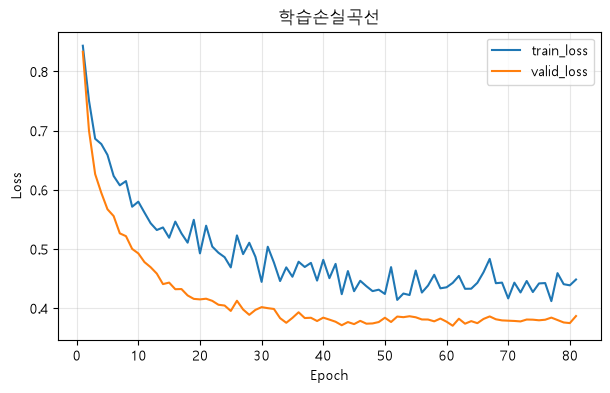

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train_loss') 
plt.plot(history_df['epoch'], history_df['valid_loss'], label='valid_loss') 
plt.title('학습손실곡선')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()    # 범례
plt.grid(alpha=0.3)
plt.show()

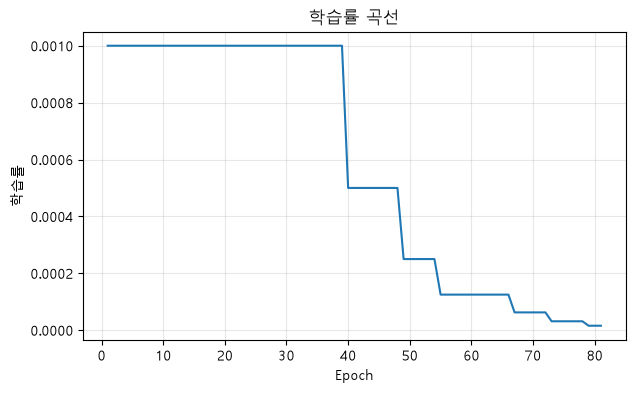

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['lr']) 
plt.title('학습률 곡선')
plt.xlabel('Epoch')
plt.ylabel('학습률')
plt.grid(alpha=0.3)
plt.show()

In [21]:
# 실제값과 모델 예측확률을 반환해주는 함수
def predict_proba(model, data_loader, device):
    model.eval()        # 평가 모드
    proba_list = []     # 예측 모드
    target_list = []    # 정답

    # 예측시 기울기 계산 비활성화
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)    # 입력 데이터만 장치로 이동

            logits = model(X_batch)         # 모델 출력 logits
            proba = torch.sigmoid(logits)   # 양성 클래스 확률로 변환

            proba_list.append(proba.cpu().numpy())  # 예측 확률을 CPU Numpy로 변환해 저장
            target_list.append(y_batch.numpy())     

        y_proba = np.vstack(proba_list).ravel() # 예측 확률을 1차원으로 변환
        y_true = np.vstack(target_list).ravel() # 정답을 1차원으로 변환

        return y_true, y_proba

- validation 데이터로 threshold 확인하고 변경하여 지표 확인
    - 기본 입계값은 0.5
    - 모델의 목적에 따라 임계값을 조정해서 사용하기도 한다.
    - 예를 들어 양성 클래스를 더 잘 잡는 걸 목표로 한다면 precision이 좀 낮아지더라도 recall 수치를 우선적으로 높일 수 있다.

In [22]:
y_valid_true, y_valid_proba = predict_proba(model, valid_loader, device)

thresholds = np.arange(0.1, 0.91, 0.05) # 0.1 ~ 0.91 전까지 0.05 텀으로 후보군 생성

thresholds_result = []

for threshold in thresholds:
    y_valid_pred = (y_valid_proba >= threshold).astype(int) # 해당 임계값 이상일시 양성(1) 판단

    thresholds_result.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_valid_true, y_valid_pred),
        'precision': precision_score(y_valid_true, y_valid_pred, zero_division=0),  # 에러발생시 0
        'recall': recall_score(y_valid_true, y_valid_pred, zero_division=0),
        'f1': f1_score(y_valid_true, y_valid_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(thresholds_result)
threshold_df.sort_values('f1', ascending=False).head()  # f1 스코어 기준 내림차순 정렬 수 5개 출력

,threshold,accuracy,precision,recall,f1
12,0.70,0.894309,0.875000,0.813953,0.843373
11,0.65,0.886179,0.837209,0.837209,0.837209
10,0.60,0.878049,0.804348,0.860465,0.831461
13,0.75,0.886179,0.891892,0.767442,0.825000
9,0.55,0.861789,0.750000,0.906977,0.821053


In [23]:
best_threshold = threshold_df.sort_values('f1', ascending=False).iloc[0]['threshold']
best_threshold

np.float64(0.7000000000000002)

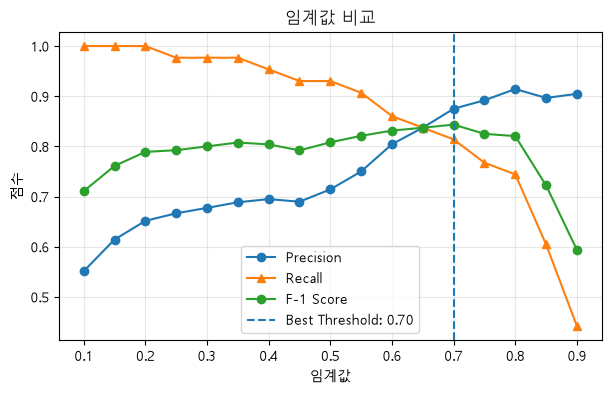

In [24]:
# 임계값별 지표 시각화
plt.figure(figsize=(7, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision') 
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='^', label='Recall') 
plt.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F-1 Score') 
plt.axvline(best_threshold, linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.title('임계값 비교')
plt.xlabel('임계값')
plt.ylabel('점수')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
# 테스트 데이터로 최종 평가

y_test_true, y_test_proba = predict_proba(model, valid_loader, device)

y_test_pred = (y_test_proba >= best_threshold).astype(int) # 해당 임계값 이상일시 양성(1) 판단

test_metrics = {
    'accuracy': accuracy_score(y_test_true, y_test_pred),
    'precision': precision_score(y_test_true, y_test_pred, zero_division=0),  # 에러발생시 0
    'recall': recall_score(y_test_true, y_test_pred, zero_division=0),
    'f1': f1_score(y_test_true, y_test_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test_true, y_test_proba),            # ROC-AUC
    # PR-AUC(AUC지표 중 Precision-Recall 곡선 아래 성능 요약하는 지표. 불균형 데이터일 경우에 한해 사용)
    'pr_auc': average_precision_score(y_test_true, y_test_proba)
}
    
pd.DataFrame([test_metrics])

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.894309,0.875,0.813953,0.843373,0.95,0.893383


In [26]:
print(classification_report(
    y_test_true, 
    y_test_pred, 
    target_names=["num_negative", "Positive"],  # 클래스 이름 
    zero_division=0 # 분모 0 나눌시 오류는 0값으로 처리
))

              precision    recall  f1-score   support

num_negative       0.90      0.94      0.92        80
    Positive       0.88      0.81      0.84        43

    accuracy                           0.89       123
   macro avg       0.89      0.88      0.88       123
weighted avg       0.89      0.89      0.89       123



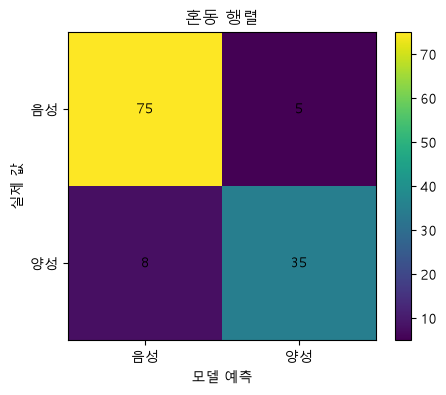

In [27]:
cm = confusion_matrix(y_test_true, y_test_pred) # 혼동 행렬 계산

plt.figure(figsize=(5, 4))
plt.imshow(cm)              # 혼동 행렬 이미지 표시
plt.title('혼동 행렬')
plt.xlabel('모델 예측')
plt.ylabel('실제 값')
plt.xticks([0, 1], ['음성', '양성'])    # x축 클래스 이름
plt.yticks([0, 1], ['음성', '양성'])    # y축 클래스 이름
plt.colorbar()                          # 색상 막대 추가

# 내부 값 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center') # 해당 셀 안에 값 표시, 수직정렬, 수평정렬

plt.show()

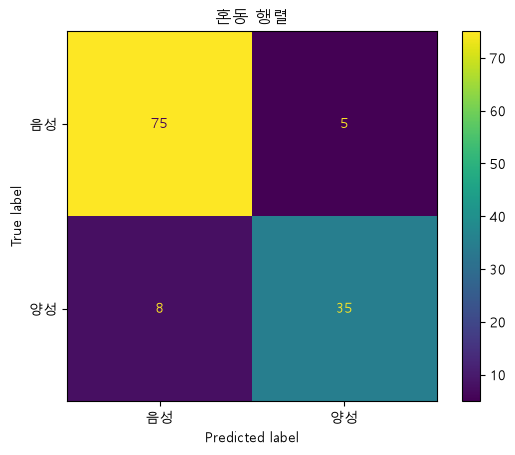

In [28]:
# ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_true, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ['음성', '양성']
)

disp.plot()
plt.title('혼동 행렬')
plt.show()

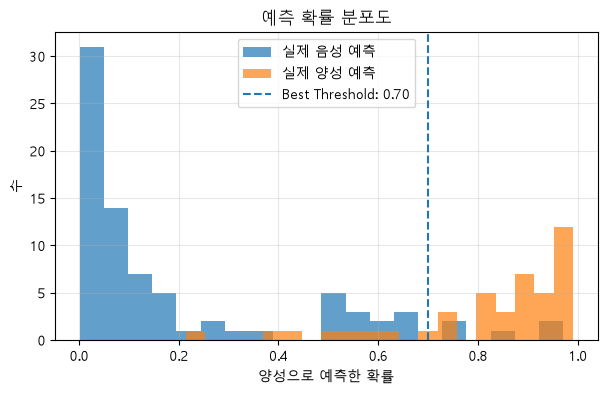

In [29]:
# 예측 확률 분포도
plt.figure(figsize=(7, 4))
plt.hist(y_test_proba[y_test_true == 0], bins=20, alpha=0.7, label='실제 음성 예측')           # 혼동 행렬 이미지 표시
plt.hist(y_test_proba[y_test_true == 1], bins=20, alpha=0.7, label='실제 양성 예측')           # 혼동 행렬 이미지 표시
plt.axvline(best_threshold, linestyle="--", label=f'Best Threshold: {best_threshold:.2f}')
plt.title('예측 확률 분포도')
plt.xlabel('양성으로 예측한 확률')
plt.ylabel('수')
plt.legend()
plt.grid(alpha=0.3)
plt.show()                          # 색상 막대 추가

In [30]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [31]:
# 샘플 데이터로 예측해보기
sample = pd.DataFrame([{
    'Pregnancies': 0,
    'Glucose': 137,
    'BloodPressure': 40,
    'SkinThickness': 35,
    'Insulin': 168,
    'BMI': 43.1,
    'DiabetesPedigreeFunction': 2.288, 
    'Age': 33
}])

sample_scaled = preprocess_pipeline.transform(sample)
sample_tensor = torch.FloatTensor(sample_scaled).to(device)

model.eval()

with torch.no_grad():
    logit = model(sample_tensor)
    proba = torch.sigmoid(logit).item()
    pred = int(proba >= best_threshold)

print(f'양성 클래스일 확률 : {proba:.4f}, 예측 클래스 : {pred}')

양성 클래스일 확률 : 0.9667, 예측 클래스 : 1
